In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
import os
import pandas as pd
import random
%matplotlib inline

In [2]:
model_name = "snf_fda-cgc"
model_output_path = os.path.join("outputs", "models", f"{model_name}.fully_annotated.result.txt")
model_output_path

'outputs/models/snf_fda-cgc.fully_annotated.result.txt'

In [3]:
data = pd.read_csv(model_output_path, sep='\t', index_col=0)
data.head()

,case,comparison,snf_fda-cgc,k,p@k,r@k,tps@k,labels_n_intersection,labels_intersection,features_intersection,labels_n_case,labels_unique_case,features_unique_case,labels_n_comparison,labels_unique_comparison,features_unique_comparison
0,ACH-000001,ACH-000893,0.995891,1.0,0.0,0.0,0,0,NaN,"BCL2 Deletion, CEBPA Amplification, CEP89 Ampl...",3,"AKT inhibitor VIII, Acetalax, rTRAIL","CACNA1D p.N1535T, CASC5 p.N618S, DCC p.N176D, ...",2,"Rucaparib, UNC0642","AFF4 p.S326L, AKAP9 p.I679L, ALK p.G452R, ALK ..."
1,ACH-000001,ACH-000670,0.995916,2.0,0.0,0.0,0,0,NaN,"CAMTA1 Amplification, ERRFI1 Amplification, FH...",3,"AKT inhibitor VIII, Acetalax, rTRAIL","CACNA1D p.N1535T, CASC5 p.N618S, DCC p.N176D, ...",3,"AGI-5198, Bryostatin 1, Savolitinib","ALK p.N941S, ASXL2 p.P752A, ATF1 p.T146R, BCOR..."
2,ACH-000001,ACH-000637,0.995918,3.0,0.0,0.0,0,0,NaN,"ASXL1 Amplification, AURKA Amplification, ERBB...",3,"AKT inhibitor VIII, Acetalax, rTRAIL","CACNA1D p.N1535T, CASC5 p.N618S, DCC p.N176D, ...",3,"BAM7, Enzastaurin, Kobe2602","AXIN2 p.A292S, BIRC6 p.S4791Y, CDKN1B p.P155L,..."
3,ACH-000001,ACH-000911,0.995929,4.0,0.0,0.0,0,0,NaN,"TSC2 p.F297fs, APOBEC3B Deletion, PDGFB Deleti...",3,"AKT inhibitor VIII, Acetalax, rTRAIL","CACNA1D p.N1535T, CASC5 p.N618S, DCC p.N176D, ...",2,"Cetuximab, Cisplatin","ACVR2A p.E93fs, ACVR2A p.K437fs, AKAP9 p.E2216..."
4,ACH-000001,ACH-000488,0.996906,5.0,0.0,0.0,0,0,NaN,"APOBEC3B Deletion, CCND2 Deletion, EXT1 Amplif...",3,"AKT inhibitor VIII, Acetalax, rTRAIL","CACNA1D p.N1535T, CASC5 p.N618S, DCC p.N176D, ...",3,"AICA Ribonucleotide, AS601245, Avagacestat","ANK1 p.A279G, ASXL1 Splice Site, ATM p.L944V, ..."


In [4]:
annotations_file = "samples.summary.txt"
annotations_path = os.path.join("inputs", "formatted", annotations_file)
annotations = pd.read_csv(annotations_path, sep='\t')
annotations.head()

,sample_name,sample_alias-ccle,sample_alias-sanger,primary_site,tumor_type,tumor_type_refined,sanger_cancer_type,sanger_cancer_type_detail
0,ACH-000001,NIHOVCAR3_OVARY,SIDM00105,Ovary,ovary,ovary,Ovarian Carcinoma,High Grade Ovarian Serous Adenocarcinoma
1,ACH-000007,LS513_LARGE_INTESTINE,SIDM00677,Large_Intestine,colorectal,colorectal,Colorectal Carcinoma,Cecum Adenocarcinoma
2,ACH-000008,A101D_SKIN,SIDM00801,Skin,melanoma,melanoma,Melanoma,Melanoma
3,ACH-000009,C2BBE1_LARGE_INTESTINE,SIDM01233,Large_Intestine,colorectal,colorectal,Colorectal Carcinoma,Colon Adenocarcinoma
4,ACH-000012,HCC827_LUNG,SIDM01067,Lung,lung_NSC,lung_NSC,Non-Small Cell Lung Carcinoma,Lung Adenocarcinoma


In [5]:
annotations['lung'] = annotations['primary_site'].eq('Lung')
annotations['lung'].value_counts()

lung
False    271
True     106
Name: count, dtype: int64

In [6]:
annotation_column = 'lung'

In [10]:
tableau10_hex = {
    'blue':   '#4e79a7',
    'orange': '#f28e2b',
    'red':    '#e15759',
    'cyan':   '#76b7b2',
    'green':  '#59a14f',
    'yellow': '#edc948',
    'purple': '#b07aa1',
    'pink':   '#e19da7',
    'brown':  '#9c755f',
    'grey':   '#bab0ac',
    'white':  '#f0f0f0'
}

def prepare_data(model_dataframe: pd.DataFrame(), number_of_neighbors: int = 1):
    neighbor_condition = model_dataframe['k'].le(number_of_neighbors)
    return model_dataframe.loc[neighbor_condition, :]

def plot_model(
    model_dataframe: pd.DataFrame(),
    model_name: str,
    annotations_dataframe: pd.DataFrame(),
    annotation_column_name: str,
    number_of_neighbors: int = 1,
    source: str = 'case',
    target: str = 'comparison',
    seed=314
):
    random.seed(seed)
    np.random.seed(seed)
    G = nx.from_pandas_edgelist(
        df=model_dataframe,
        source=source,
        target=target,
        edge_attr=True,
        create_using=nx.DiGraph()
    )
    d = dict(G.degree)

    if annotations_dataframe.index.name != "sample_name":
        annotations_dataframe = annotations_dataframe.set_index('sample_name')
    annotations_dataframe.reindex(G.nodes())

    annotations_dataframe[annotation_column_name] = pd.Categorical(annotations_dataframe[annotation_column_name])
    annotation_nodes = annotations_dataframe.reindex(G.nodes())

    fig, ax = plt.subplots(figsize=(8,8))
    ax.set_title(f"{model_name} nearest neighbors")
    
    color_map = {
        False: tableau10_hex['grey'],
        True: tableau10_hex['blue']
    }
    node_colors = annotations_dataframe[annotation_column_name].map(color_map)

    p1 = nx.draw_spring(
        G=G,
        with_labels=False,
        font_size=6,
        node_size=[v * 100 for v in d.values()],
        node_color=node_colors,
        alpha=0.75
    )

    legend_handles = [
        mpatches.Patch(color=color, label=category)
        for category, color in color_map.items()
    ]
    plt.legend(handles=legend_handles, title=annotation_column_name, frameon=False)
    
    return p1, G, color_map

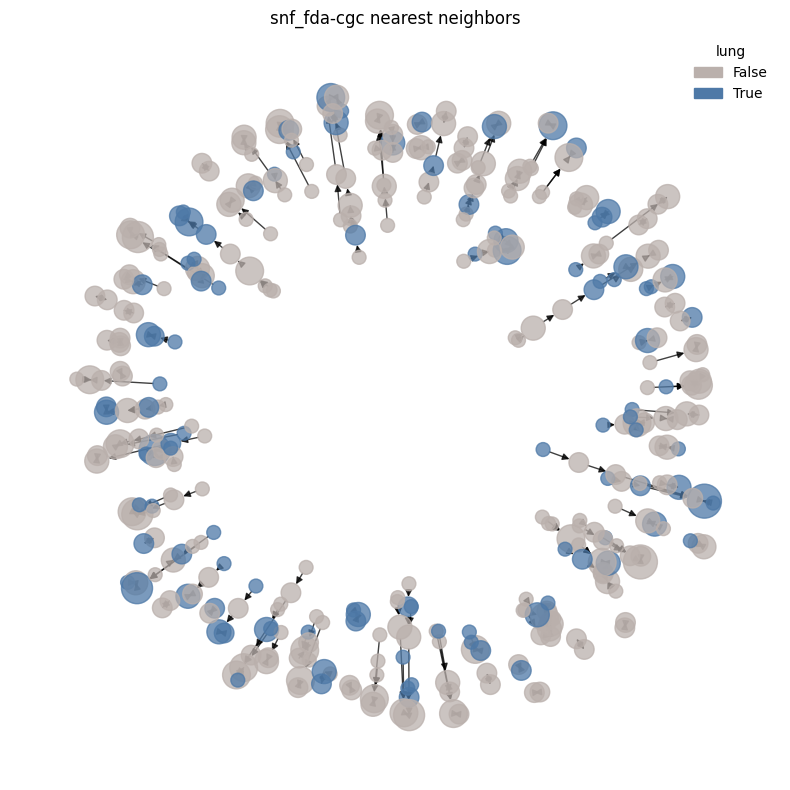

In [12]:
save_figure = False
model_dataframe = data,
number_of_neighbors = 1

data_to_plot = prepare_data(
    model_dataframe = data,
    number_of_neighbors = 1
)
figure, graph_object, cmap = plot_model(
    model_dataframe = data_to_plot,
    model_name = model_name,
    annotations_dataframe = annotations,
    annotation_column_name = annotation_column,
    number_of_neighbors = number_of_neighbors
)

plt.tight_layout()

if save_figure:
    filename = f'{model_name}.{annotation_column}.nearest_neighbors'
    for suffix in ['png', 'svg']:
        outname = f"{filename}.{suffix}"
        plt.savefig(outname, format=suffix, bbox_inches='tight', dpi=300)

plt.show()